# 02 · Best-20 Site Search

Consumes the Suitability Index raster (`UK_Final_Suitability_Score.tif`) and identifies the **20 optimal 0.5 GW wind-farm clusters** (10 GW total).

**Method:** geometric kernel library → 2D convolution for cumulative potential → greedy turbine placement (81 × 6 MW per 125 km² footprint) enforcing wake-spacing → global ranking by mean suitability → regional quotas (Scotland/England/Wales/NI) with fallback to Scotland.

> Requires `./Sripts/Output/UK_Final_Suitability_Score.tif` produced by notebook 01.

## Site-searching algorithm (with regional-quota fallback)
Generates geometric kernels (square, circle, 3:1 & 5:1 ellipses rotated in 22.5° steps), convolves them over the Suitability Index to find high-potential footprints, places 81 turbines per 125 km² site with a minimum wake-spacing distance, and allocates 20 sites under regional quotas with a Scotland fallback.

In [9]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import cv2
import os

# --- 1. KERNEL ERSTELLUNG ---
def create_kernels(side_px):
    """Erstellt geometrische Formen mit einer Brutto-Fläche von 125km2."""
    kernels = []
    target_area_px = side_px**2
    canvas_size = int(side_px * 2.5) # Puffer für schmale 5:1 Ellipsen
    center = canvas_size // 2
    
    # Quadrat
    rect = np.ones((side_px, side_px), dtype=np.float32)
    kernels.append({'name': 'Rectangle', 'raw': rect})
    
    # Kreis
    r_circle = int(np.round(np.sqrt(target_area_px / np.pi)))
    circle_mask = np.zeros((canvas_size, canvas_size), dtype=np.float32)
    cv2.circle(circle_mask, (center, center), r_circle, 1, -1)
    kernels.append({'name': 'Circle', 'raw': circle_mask})
    
    # 8 Rotationswinkel (22.5° Schritte)
    angles = [i * 22.5 for i in range(8)]
    
    # Ellipsen (3:1 und 5:1 Verhältnis)
    for ratio in [3, 5]:
        b = np.sqrt(target_area_px / (ratio * np.pi))
        a = ratio * b
        axes = (int(np.round(a)), int(np.round(b)))
        for angle in angles:
            ell_mask = np.zeros((canvas_size, canvas_size), dtype=np.float32)
            cv2.ellipse(ell_mask, (center, center), axes, angle, 0, 360, 1, -1)
            kernels.append({'name': f'Ellipse_{ratio}-1_{angle}°', 'raw': ell_mask})
    return kernels

# --- 2. HILFSFUNKTION: REGIONEN ALIGNMENT ---
def load_and_align_regions(base_profile, region_files):
    """Projiziert regionale TIFs auf das Master-Raster-Gitter."""
    master_shape = (base_profile['height'], base_profile['width'])
    combined_mask = np.zeros(master_shape, dtype=np.int32)
    for rid, path in region_files.items():
        if not os.path.exists(path):
            print(f"Warnung: Datei nicht gefunden: {path}")
            continue
        with rasterio.open(path) as src:
            region_data = np.zeros(master_shape, dtype=np.float32)
            reproject(
                source=rasterio.band(src, 1), destination=region_data,
                src_transform=src.transform, src_crs=src.crs,
                dst_transform=base_profile['transform'], dst_crs=base_profile['crs'],
                resampling=Resampling.nearest
            )
            combined_mask[region_data > 0] = rid
    return combined_mask

# --- 3. HAUPTANALYSE MIT PRÄZISER SPERRUNG ---
def run_spatial_assessment_with_fallback(tif_path, region_files, quotas, num_turbines=81, min_dist_px=11):
    print("--- STARTE ANALYSE (FIX: KEINE ÜBERLAPPUNGEN) ---")
    
    # Suitability Daten laden
    with rasterio.open(tif_path) as src:
        scores = src.read(1).astype(np.float32)
        scores = np.where(scores > 0, scores, 0)
        base_profile = src.profile
        res_x, res_y = src.res

    # Regionen-Maske erstellen
    regions_mask = load_and_align_regions(base_profile, region_files)
    
    # Pixel-Maße für 125km2 berechnen
    pixel_area_km2 = (abs(res_x) * abs(res_y)) / 1e6
    side_px = int(np.sqrt(125.0 / pixel_area_km2))
    kernels = create_kernels(side_px)
    
    all_candidates = []

    # Schritt 1: Potenzielle Kandidaten über alle Formen sammeln
    for k in kernels:
        print(f"Scanne Form: {k['name']}...", end=" ", flush=True)
        suit_sum = cv2.filter2D(scores, -1, k['raw'])
        temp_layer = np.copy(suit_sum)
        h_k, w_k = k['raw'].shape

        for _ in range(150): 
            idx = np.argmax(temp_layer)
            r, c = np.unravel_index(idx, temp_layer.shape)
            if temp_layer[r, c] <= 0: break
            
            rid = int(regions_mask[r, c])
            if rid == 0:
                temp_layer[r, c] = 0
                continue

            # Fenster für Turbinen-Check
            r0, r1 = max(0, r-h_k//2), min(scores.shape[0], r+h_k//2)
            c0, c1 = max(0, c-w_k//2), min(scores.shape[1], c+w_k//2)
            win_data = scores[r0:r1, c0:c1]
            m_r0, m_c0 = (0 if r-h_k//2 >= 0 else -(r-h_k//2)), (0 if c-w_k//2 >= 0 else -(c-w_k//2))
            win_mask = k['raw'][m_r0:m_r0+(r1-r0), m_c0:m_c0+(c1-c0)]
            
            coords = np.argwhere((win_mask > 0) & (win_data > 0))
            if len(coords) >= num_turbines:
                # Turbinen-Placement innerhalb der Form
                available = np.argsort([win_data[rr, cc] for rr, cc in coords])[::-1]
                sel, occ = [], np.zeros(win_data.shape, dtype=bool)
                for i_c in available:
                    rr, cc = coords[i_c]
                    if not occ[rr, cc]:
                        sel.append((rr, cc))
                        cv2.circle(occ.view(np.uint8), (cc, rr), min_dist_px, 1, -1)
                    if len(sel) >= num_turbines: break
                
                if len(sel) == num_turbines:
                    avg_score = np.mean([win_data[rr, cc] for rr, cc in sel])
                    all_candidates.append({
                        'center': (r, c),
                        'suit_idx': float(avg_score),
                        'region_id': rid,
                        'shape_name': k['name'],
                        'selection_coords': np.array(sel),
                        'kernel_raw': k['raw'] # Wichtig für exakte Sperrung
                    })
            
            # Punktuelle Sperrung im temp_layer für die nächste Iteration des gleichen Kernels
            temp_layer[max(0, r-side_px//4):min(scores.shape[0], r+side_px//4), 
                       max(0, c-side_px//4):min(scores.shape[1], c+side_px//4)] = 0
        print("Done.")

    # Schritt 2: Globales Ranking und exakte Flächensperrung
    all_candidates.sort(key=lambda x: x['suit_idx'], reverse=True)
    
    final_sites = []
    # Maske, die die gesamte Geometrie sperrt (0 = frei, 255 = belegt)
    global_taken_mask = np.zeros(scores.shape, dtype=np.uint8)
    current_counts = {rid: 0 for rid in quotas.keys()}
    
    def try_add_site_precisely(s):
        r, c = s['center']
        mask_k = s['kernel_raw']
        h_k, w_k = mask_k.shape
        
        r0, r1 = max(0, r-h_k//2), min(scores.shape[0], r+h_k//2)
        c0, c1 = max(0, c-w_k//2), min(scores.shape[1], c+w_k//2)
        
        m_r0, m_c0 = (0 if r-h_k//2 >= 0 else -(r-h_k//2)), (0 if c-w_k//2 >= 0 else -(c-w_k//2))
        current_shape_mask = mask_k[m_r0:m_r0+(r1-r0), m_c0:m_c0+(c1-c0)]
        
        # Überlappungs-Check: Ist einer der Pixel in der neuen Form bereits belegt?
        overlap = np.any((global_taken_mask[r0:r1, c0:c1] > 0) & (current_shape_mask > 0))
        
        if not overlap:
            # Exakte Form in die Sperrmaske einzeichnen
            global_taken_mask[r0:r1, c0:c1] = np.maximum(
                global_taken_mask[r0:r1, c0:c1], 
                (current_shape_mask * 255).astype(np.uint8)
            )
            return True
        return False

    # Quoten füllen
    for s in all_candidates:
        rid = s['region_id']
        if current_counts.get(rid, 0) < quotas.get(rid, 0):
            if try_add_site_precisely(s):
                final_sites.append(s)
                current_counts[rid] += 1

    # Fallback-Logik (Wales -> Scotland)
    total_needed = sum(quotas.values())
    if len(final_sites) < total_needed:
        print(f"Defizit: Nur {len(final_sites)}/{total_needed} gefunden. Starte Fallback...")
        for fb_id in [3, 1]: # Wales, dann Schottland
            for s in all_candidates:
                if s['region_id'] == fb_id and len(final_sites) < total_needed:
                    if try_add_site_precisely(s):
                        final_sites.append(s)
                        current_counts[fb_id] += 1

    print("\n--- FINALE STATISTIK ---")
    for rid, q in quotas.items():
        print(f"Region {rid}: {current_counts[rid]}/{q}")
        
    return final_sites, scores, side_px

# --- 4. PARAMETER & PFADE ---
base_path = './Sripts/Output'
suitability_tif = os.path.join(base_path, 'UK_Final_Suitability_Score.tif')

region_files = {
    1: os.path.join(base_path, 'scotland_spatial_assessment.tif'),
    2: os.path.join(base_path, 'england_spatial_assessment.tif'),
    3: os.path.join(base_path, 'wales_spatial_assessment.tif'),
    4: os.path.join(base_path, 'northern_ireland_spatial_assessment.tif')
}

target_quotas = {1: 14, 2: 2, 3: 2, 4: 2}

# AUSFÜHRUNG
final_results, raw_data, side_px = run_spatial_assessment_with_fallback(
    suitability_tif, region_files, target_quotas
)

--- STARTE ANALYSE (FIX: KEINE ÜBERLAPPUNGEN) ---
Scanne Form: Rectangle... Done.
Scanne Form: Circle... Done.
Scanne Form: Ellipse_3-1_0.0°... Done.
Scanne Form: Ellipse_3-1_22.5°... Done.
Scanne Form: Ellipse_3-1_45.0°... Done.
Scanne Form: Ellipse_3-1_67.5°... Done.
Scanne Form: Ellipse_3-1_90.0°... Done.
Scanne Form: Ellipse_3-1_112.5°... Done.
Scanne Form: Ellipse_3-1_135.0°... Done.
Scanne Form: Ellipse_3-1_157.5°... Done.
Scanne Form: Ellipse_5-1_0.0°... Done.
Scanne Form: Ellipse_5-1_22.5°... Done.
Scanne Form: Ellipse_5-1_45.0°... Done.
Scanne Form: Ellipse_5-1_67.5°... Done.
Scanne Form: Ellipse_5-1_90.0°... Done.
Scanne Form: Ellipse_5-1_112.5°... Done.
Scanne Form: Ellipse_5-1_135.0°... Done.
Scanne Form: Ellipse_5-1_157.5°... Done.
Defizit: Nur 17/20 gefunden. Starte Fallback...

--- FINALE STATISTIK ---
Region 1: 17/14
Region 2: 0/2
Region 3: 2/2
Region 4: 1/2


## Map of the suggested sites

Lese Daten ein und korrigiere Ausrichtung (Shetland wird ausgeschlossen)...
Karte ohne Shetlands unter uk_spatial_assessment_fixed.png gespeichert.


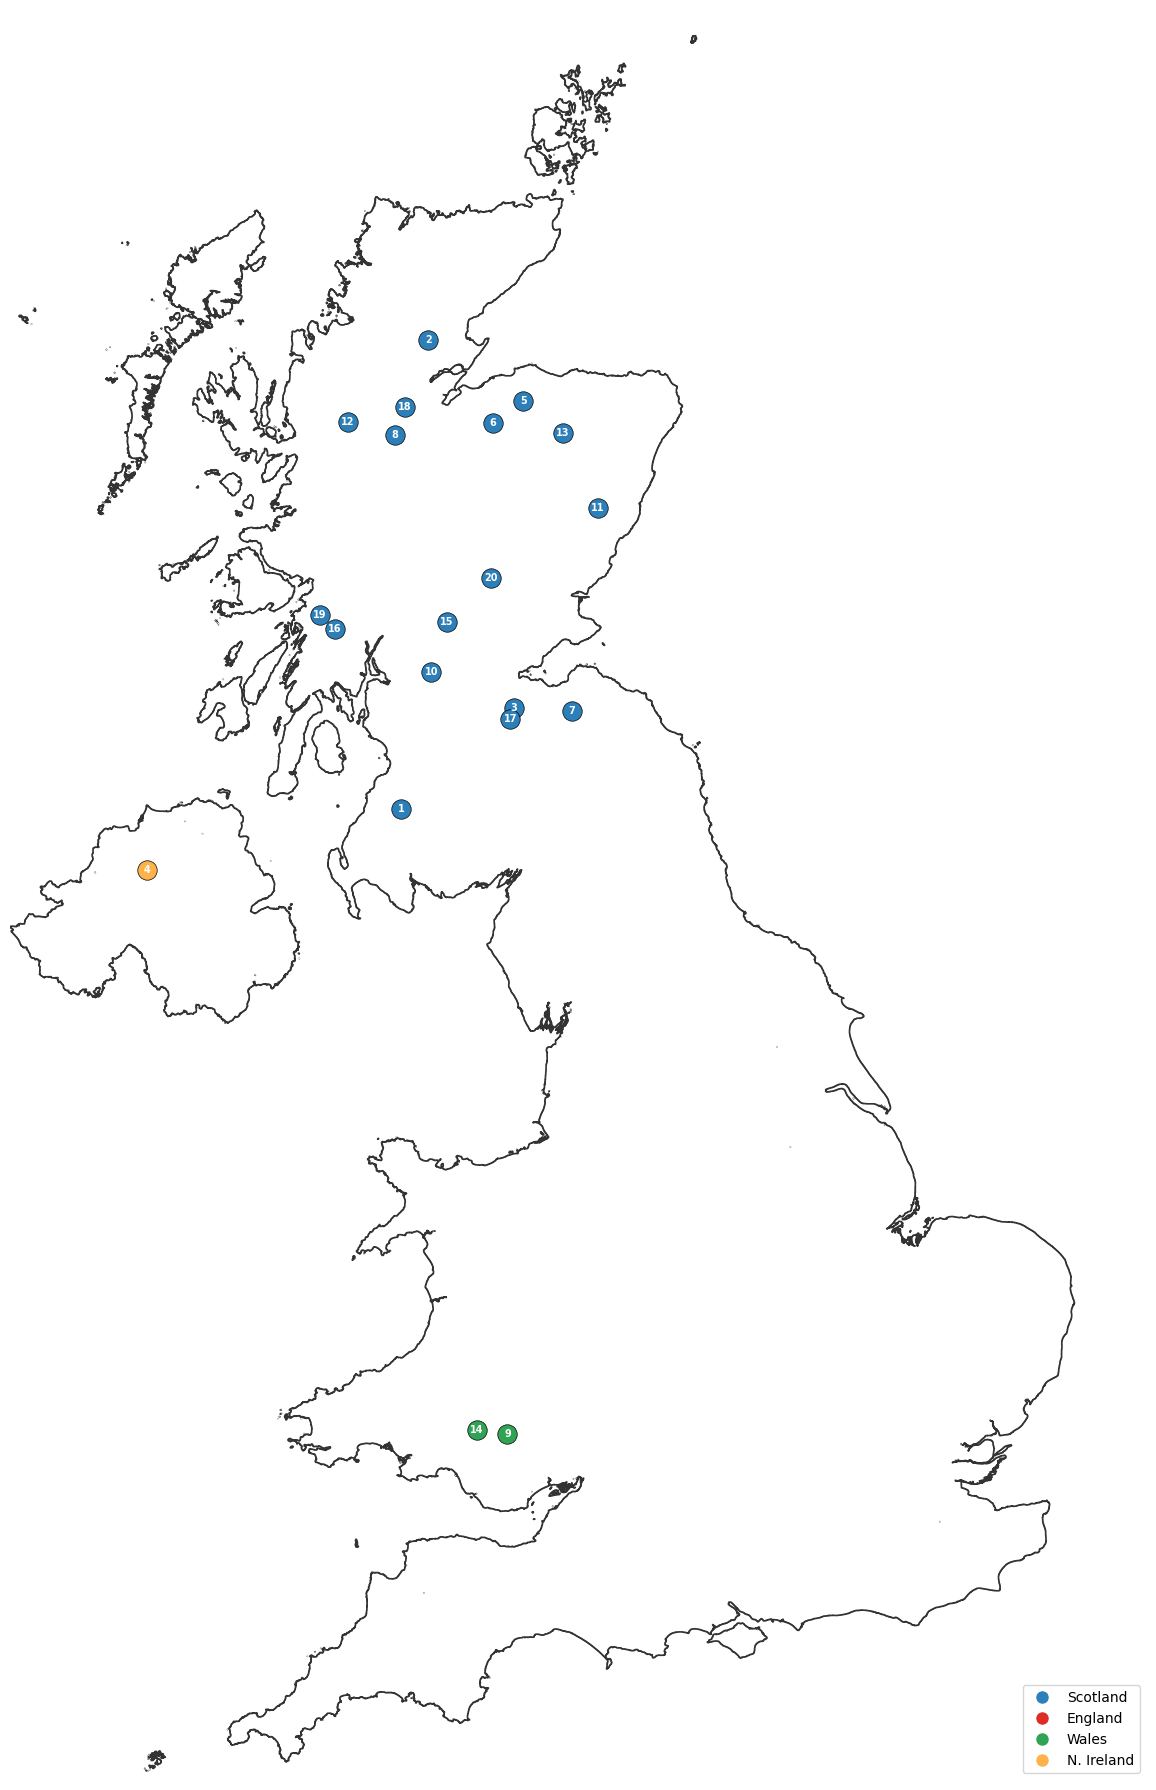

In [28]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.lines import Line2D

def plot_sites_fixed(sites, data_path, outline_path, output_file='uk_spatial_assessment_fixed.png'):
    print("Lese Daten ein und korrigiere Ausrichtung (Shetland wird ausgeschlossen)...")
    
    with rasterio.open(data_path) as src_data:
        b = src_data.bounds
        extent = [b.left, b.right, b.bottom, b.top]
        
    outline = None
    if os.path.exists(outline_path):
        with rasterio.open(outline_path) as src_outline:
            # Hier stellen wir sicher, dass der Umriss die gleiche Form wie die Daten hat
            outline = src_outline.read(1, out_shape=(src_data.height, src_data.width))

    fig, ax = plt.subplots(figsize=(12, 18), facecolor='white')
    ax.set_facecolor('white')

    # 1. HINTERGRUND & UMREISS
    if outline is not None:
        ax.contour(outline, levels=[0.5], colors='#333333', linewidths=1.2, 
                   extent=extent, origin='upper', zorder=2)
        
        ax.imshow(np.where(outline > 0, 1, np.nan), cmap='Greys', alpha=0.05,
                  extent=extent, origin='upper', interpolation='nearest')

    # 2. STANDORTE
    region_colors = {1: '#2c7fb8', 2: '#de2d26', 3: '#31a354', 4: '#feb24c'}
    
    for i, site in enumerate(sites, 1):
        r, c = site['center']
        rid = site['region_id']
        color = region_colors.get(rid, '#636363')
        
        # Umrechnung von Pixel-Indizes in Karten-Koordinaten
        with rasterio.open(data_path) as src:
            x_coord, y_coord = src.xy(r, c)
        
        # Zeichnen der Punkte
        ax.plot(x_coord, y_coord, 'o', markersize=14, color=color, 
                markeredgecolor='black', markeredgewidth=0.5, zorder=5)
        
        ax.text(x_coord, y_coord, str(i), color='white', fontsize=7, 
                fontweight='bold', ha='center', va='center', zorder=6)

    # --- SHETLANDS AUSSCHLIESSEN ---
    # Wir begrenzen die Ansicht auf das Festland + Orkney
    # X-Bereich: ca. 0 bis 700.000 | Y-Bereich: 0 bis 1.050.000
    ax.set_ylim(0, 1090000)
    ax.set_xlim(0, 700000)

    # 3. FORMATIERUNG
    # Wir nutzen nicht ax.axis('off'), damit die Limits sicher greifen, 
    # schalten aber die Ticks manuell aus:
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Scotland', markerfacecolor='#2c7fb8', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='England', markerfacecolor='#de2d26', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Wales', markerfacecolor='#31a354', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='N. Ireland', markerfacecolor='#feb24c', markersize=10)
    ]
    ax.legend(handles=legend_elements, loc='lower right', frameon=True, facecolor='white')

    plt.tight_layout()
    # Hinweis: plt.show() wird gemäß deinen Vorgaben weggelassen
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Karte ohne Shetlands unter {output_file} gespeichert.")

# --- AUSFÜHRUNG ---
if 'final_results' in locals():
    # Achte darauf, dass die Variablen suitability_tif und outline_tif definiert sind
    plot_sites_fixed(final_results, suitability_tif, outline_tif)
else:
    print("Fehler: Keine Daten (final_results) zum Plotten vorhanden.")

## Detailed close-up views of each proposed site

Erstelle 20 Nahaufnahmen...
Detaillierte Grafik erfolgreich als 'spatial_assessment_zoomed.png' gespeichert.


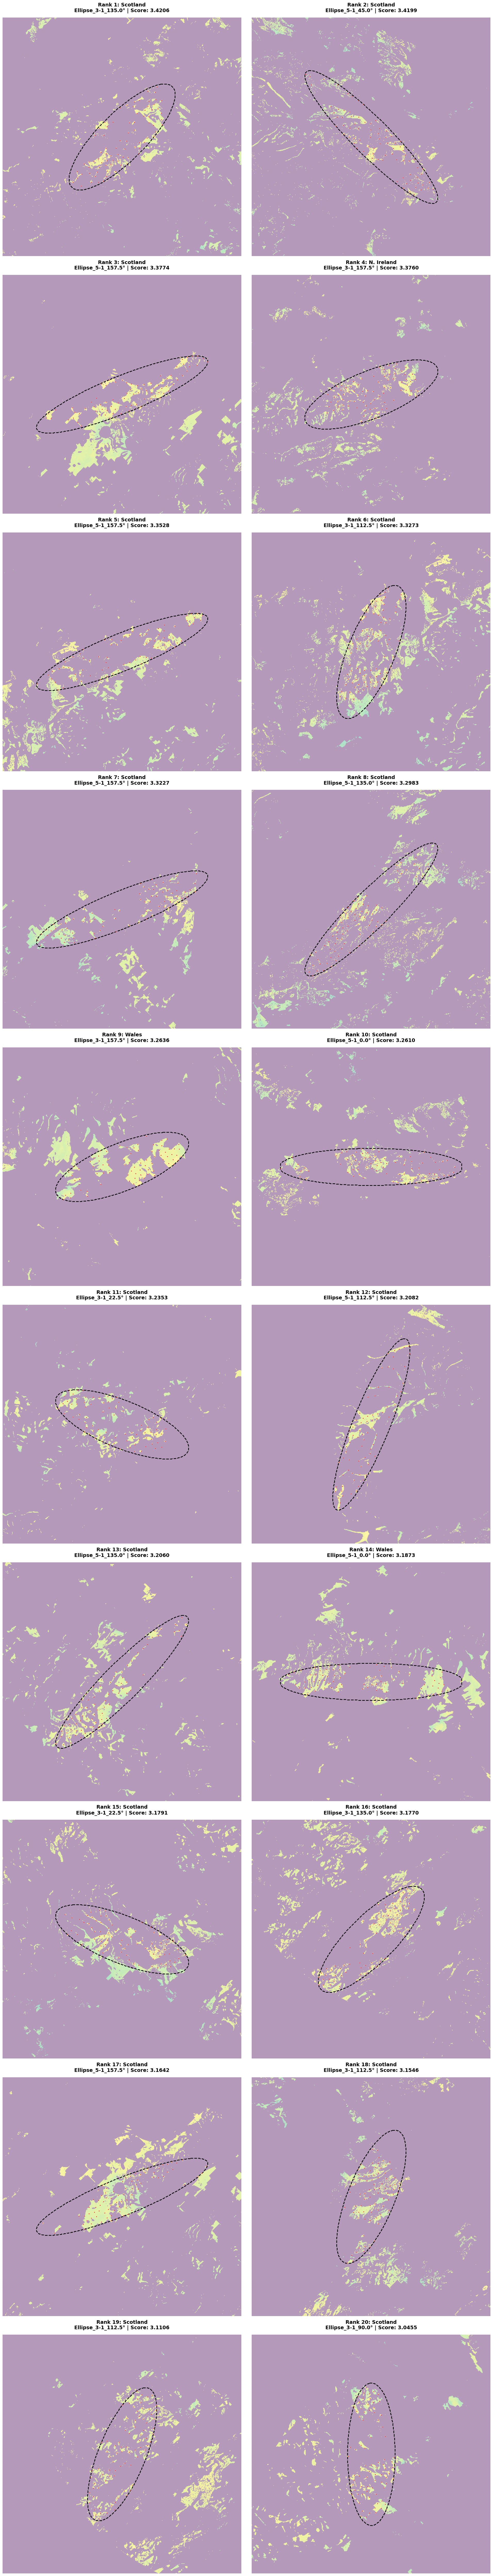

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

def plot_spatial_assessment_results_zoom(sites, data, side_px):
    """
    Erstellt detaillierte Nahaufnahmen aller gefundenen Standorte.
    Berücksichtigt die neuen 3:1 und 5:1 Ellipsen-Typen.
    """
    num_actual = len(sites)
    if num_actual == 0:
        print("Keine Ergebnisse in der Liste gefunden.")
        return
        
    # Kernels für die Visualisierung basierend auf side_px neu generieren
    all_kernels = create_kernels(side_px)
    kernels_dict = {k['name']: k['raw'] for k in all_kernels}
    
    # Layout-Berechnung
    cols = 2
    rows = (num_actual + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 10), facecolor='white', squeeze=False)
    axes_flat = axes.flatten()

    region_names = {1: "Scotland", 2: "England", 3: "Wales", 4: "N. Ireland"}

    print(f"Erstelle {num_actual} Nahaufnahmen...")

    for i in range(len(axes_flat)):
        ax = axes_flat[i]
        if i < num_actual:
            s = sites[i]
            r_cnt, c_cnt = s['center']
            shape_name = s['shape_name']
            rid = s['region_id']
            
            # Kernel-Zuordnung aus dem Dictionary
            if shape_name not in kernels_dict:
                print(f"Hinweis: Kernel '{shape_name}' nicht gefunden. Nutze Fallback-Visualisierung.")
                # Falls der Name nicht exakt matcht, nehmen wir die gespeicherte Form direkt
                orig_kernel = s['kernel_raw'] 
            else:
                orig_kernel = kernels_dict[shape_name]
            
            h_m, w_m = orig_kernel.shape
            
            # 1. Fensterausschnitt (Original-Position)
            r0, r1 = max(0, r_cnt - h_m//2), min(data.shape[0], r_cnt + h_m//2)
            c0, c1 = max(0, c_cnt - w_m//2), min(data.shape[1], c_cnt + w_m//2)
            
            # 2. Zoom-Padding (Vergrößert den Ausschnitt für besseren Kontext)
            pad = int(side_px * 0.4) 
            p_r0, p_r1 = max(0, r0-pad), min(data.shape[0], r1+pad)
            p_c0, p_c1 = max(0, c0-pad), min(data.shape[1], c1+pad)
            crop_data = data[p_r0:p_r1, p_c0:p_c1]
            
            # Hintergrund: Suitability Score
            ax.imshow(crop_data, cmap='viridis', alpha=0.4, origin='upper')
            
            # 3. Brutto-Fläche (Gesperrte 125km2 Geometrie)
            full_mask_layer = np.zeros(crop_data.shape)
            m_r0 = 0 if r_cnt - h_m//2 >= 0 else -(r_cnt - h_m//2)
            m_c0 = 0 if c_cnt - w_m//2 >= 0 else -(c_cnt - w_m//2)
            
            plot_offset_r = r0 - p_r0
            plot_offset_c = c0 - p_c0
            
            h_cut, w_cut = (r1 - r0), (c1 - c0)
            mask_part = orig_kernel[m_r0:m_r0+h_cut, m_c0:m_c0+w_cut]
            full_mask_layer[plot_offset_r:plot_offset_r+h_cut, 
                            plot_offset_c:plot_offset_c+w_cut] = mask_part

            # Zeichne Umriss der Form
            ax.contour(full_mask_layer, levels=[0.5], colors=['black'], linewidths=2, linestyles='--')
            
            # 4. Netto-Layout: Die 81 Turbinen
            # Die Koordinaten sind relativ zum Start des Fensters (r0, c0) gespeichert
            for tr, tc in s['selection_coords']:
                final_r = (tr + r0) - p_r0
                final_c = (tc + c0) - p_c0
                ax.plot(final_c, final_r, 'r.', markersize=5, markeredgecolor='white', markeredgewidth=0.3)

            # Beschriftung
            r_label = region_names.get(rid, f"Region {rid}")
            ax.set_title(f"Rank {i+1}: {r_label}\n{shape_name} | Score: {s['suit_idx']:.4f}", 
                         fontsize=14, fontweight='bold', pad=15)
        
        ax.axis('off')

    plt.tight_layout()
    # Speichern laut User-Vorgabe (plt.show() wird vermieden)
    plt.savefig('spatial_assessment_zoomed.png', dpi=200, bbox_inches='tight')
    print(f"Detaillierte Grafik erfolgreich als 'spatial_assessment_zoomed.png' gespeichert.")

# --- START DES PLOTTINGS ---
# Nutzt die Variablen 'final_results' und 'raw_data' aus dem 6-Minuten-Lauf
if 'final_results' in locals():
    plot_spatial_assessment_results_zoom(final_results, raw_data, side_px)
else:
    print("Fehler: Variable 'final_results' nicht gefunden. Bitte Analyse-Code zuerst ausführen.")

In [25]:
import matplotlib.pyplot as plt
import numpy as np

def plot_spatial_assessment_batched(sites, data, side_px, batch_size=12):
    """
    Plottet die Ergebnisse in 3er-Raster-Blöcken (max 12 pro Bild).
    Speichert für jeden Block eine eigene Datei.
    """
    num_actual = len(sites)
    if num_actual == 0:
        print("Keine Ergebnisse gefunden.")
        return
        
    all_kernels = create_kernels(side_px)
    kernels_dict = {k['name']: k['raw'] for k in all_kernels}
    region_names = {1: "Scotland", 2: "England", 3: "Wales", 4: "N. Ireland"}

    # Aufteilen der Ergebnisse in Batches
    for batch_idx in range(0, num_actual, batch_size):
        current_batch = sites[batch_idx : batch_idx + batch_size]
        num_in_batch = len(current_batch)
        
        cols = 3
        rows = (num_in_batch + cols - 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=(24, rows * 7), facecolor='white', squeeze=False)
        axes_flat = axes.flatten()

        for i in range(len(axes_flat)):
            ax = axes_flat[i]
            if i < num_in_batch:
                s = current_batch[i]
                rank = batch_idx + i + 1
                r_cnt, c_cnt = s['center']
                shape_name = s['shape_name']
                rid = s['region_id']
                
                orig_kernel = kernels_dict.get(shape_name, s.get('kernel_raw'))
                h_m, w_m = orig_kernel.shape
                
                # Koordinaten-Berechnung
                r0, r1 = max(0, r_cnt - h_m//2), min(data.shape[0], r_cnt + h_m//2)
                c0, c1 = max(0, c_cnt - w_m//2), min(data.shape[1], c_cnt + w_m//2)
                pad = int(side_px * 0.4) 
                p_r0, p_r1 = max(0, r0-pad), min(data.shape[0], r1+pad)
                p_c0, p_c1 = max(0, c0-pad), min(data.shape[1], c1+pad)
                
                crop_data = data[p_r0:p_r1, p_c0:p_c1]
                ax.imshow(crop_data, cmap='viridis', alpha=0.4, origin='upper')
                
                # Masken-Overlay für Umriss
                full_mask_layer = np.zeros(crop_data.shape)
                plot_offset_r, plot_offset_c = r0 - p_r0, c0 - p_c0
                h_cut, w_cut = (r1 - r0), (c1 - c0)
                m_r0 = 0 if r_cnt - h_m//2 >= 0 else -(r_cnt - h_m//2)
                m_c0 = 0 if c_cnt - w_m//2 >= 0 else -(c_cnt - w_m//2)
                
                mask_part = orig_kernel[m_r0:m_r0+h_cut, m_c0:m_c0+w_cut]
                full_mask_layer[plot_offset_r:plot_offset_r+h_cut, 
                                plot_offset_c:plot_offset_c+w_cut] = mask_part

                ax.contour(full_mask_layer, levels=[0.5], colors=['black'], linewidths=1.5, linestyles='--')
                
                # Turbinen
                for tr, tc in s['selection_coords']:
                    ax.plot((tc + c0) - p_c0, (tr + r0) - p_r0, 'r.', markersize=4, markeredgecolor='white', markeredgewidth=0.2)

                ax.set_title(f"Rank {rank}: {region_names.get(rid, f'Region {rid}')}\n{shape_name} | Score: {s['suit_idx']:.4f}", 
                             fontsize=12, fontweight='bold')
            else:
                ax.set_visible(False)
            ax.axis('off')

        plt.tight_layout()
        filename = f'spatial_assessment_batch_{batch_idx//batch_size + 1}.png'
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        plt.close(fig) # Speicher freigeben
        print(f"Batch gespeichert als: {filename}")

# Start
if 'final_results' in locals():
    plot_spatial_assessment_batched(final_results, raw_data, side_px, batch_size=12)

Batch gespeichert als: spatial_assessment_batch_1.png
Batch gespeichert als: spatial_assessment_batch_2.png


## Per-site statistics (grid distance, regional scores)

In [26]:
import pandas as pd
import geopandas as gpd
import rasterio
from shapely.geometry import Point
import os

def calculate_site_statistics(sites, tif_path, grid_path):
    """
    Berechnet die Distanz zum Stromnetz und fasst die regionalen Daten 
    sowie Scores in einer Tabelle zusammen.
    """
    if not os.path.exists(grid_path):
        print(f"Fehler: Grid-Datei nicht gefunden unter {grid_path}")
        return None

    # 1. Stromleitungen laden und in British National Grid (EPSG:27700) transformieren
    print("Lade Stromleitungen und berechne Distanzen...")
    grid_gdf = gpd.read_file(grid_path)
    if grid_gdf.crs != "EPSG:27700":
        grid_gdf = grid_gdf.to_crs("EPSG:27700")
    
    # Für die Distanzberechnung ist ein unary_union effizienter
    merged_grid = grid_gdf.unary_union
    
    region_names = {1: "Scotland", 2: "England", 3: "Wales", 4: "N. Ireland"}
    results = []
    
    with rasterio.open(tif_path) as src:
        for i, s in enumerate(sites):
            row, col = s['center']
            
            # Pixel-Koordinaten in BNG Easting/Northing umwandeln
            easting, northing = src.xy(row, col, offset='center')
            site_point = Point(easting, northing)
            
            # Distanz zur nächsten Leitung berechnen
            distance_meters = site_point.distance(merged_grid)
            
            # Alle relevanten Daten sammeln
            results.append({
                'Rank': i + 1,
                'Region': region_names.get(s['region_id'], "Unknown"),
                'Shape': s['shape_name'],
                'Avg_Suitability': round(s['suit_idx'], 4),
                'Turbines': len(s['selection_coords']),
                'Easting': round(easting, 1),
                'Northing': round(northing, 1),
                'Grid_Dist_km': round(distance_meters / 1000, 3)
            })
            
    df = pd.DataFrame(results)
    return df

# --- AUSFÜHRUNG ---
# Nutzt 'final_results' aus dem letzten Analyse-Durchlauf
path_transmission_lines = './Data/Transmission Lines/GridUK275kV-iflenght>=200.geojson'
tif_path_analysis = './Sripts/Output/UK_Final_Suitability_Score.tif'

if 'final_results' in locals():
    df_grid_stats = calculate_site_statistics(final_results, tif_path_analysis, path_transmission_lines)
    
    if df_grid_stats is not None:
        print("\n--- STATISTIK DER STANDORTE ---")
        # Zeige die gesamte Tabelle
        print(df_grid_stats.to_string(index=False))
        
        # Optional: Speichern als CSV
        output_csv = 'spatial_assessment_grid_stats.csv'
        df_grid_stats.to_csv(output_csv, index=False)
        print(f"\nStatistik wurde als '{output_csv}' gespeichert.")
else:
    print("Variable 'final_results' nicht gefunden. Bitte führe zuerst die Analyse-Zelle aus.")

Lade Stromleitungen und berechne Distanzen...

--- STATISTIK DER STANDORTE ---
 Rank     Region              Shape  Avg_Suitability  Turbines  Easting  Northing  Grid_Dist_km
    1   Scotland Ellipse_3-1_135.0°           3.4206        81 240692.2  597833.3         0.466
    2   Scotland  Ellipse_5-1_45.0°           3.4199        81 257492.2  886900.0         3.116
    3   Scotland Ellipse_5-1_157.5°           3.3774        81 310158.8  660166.7         2.799
    4 N. Ireland Ellipse_3-1_157.5°           3.3760        81  84492.2  560700.0         0.875
    5   Scotland Ellipse_5-1_157.5°           3.3528        81 316158.8  849300.0         3.586
    6   Scotland Ellipse_3-1_112.5°           3.3273        81 297158.8  835966.7         8.089
    7   Scotland Ellipse_5-1_157.5°           3.3227        81 346092.2  658566.7         1.875
    8   Scotland Ellipse_5-1_135.0°           3.2983        81 237225.5  828500.0         4.581
    9      Wales Ellipse_3-1_157.5°           3.2636     

/var/folders/dg/5x29cr055g5dhhm3kh7dkd5h0000gn/T/ipykernel_10657/4013376245.py:23: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  merged_grid = grid_gdf.unary_union
